In [1]:
import warnings

import dask.dataframe as dd
import pyarrow.parquet as pq
import pyarrow as pa

import pandas as pd
import numpy as np
from fastparquet import write

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from scipy.stats import norm

import json
import gc
import glob
from pathlib import Path
import time

## Loading and dataset column splitting into categories

In [2]:
df_centrooeste = pd.read_csv("2024/centrooeste_natan2024.txt")
df_centrooeste.head(3)

,Bairros SP - Código,Bairros Fortaleza - Código,Bairros RJ - Código,Causa Afastamento 1 - Código,Causa Afastamento 2 - Código,Causa Afastamento 3 - Código,Motivo Desligamento - Código,CBO 2002 Ocupação - Código,CNAE 2.0 Classe - Código,CNAE 95 Classe - Código,...,Vl Rem Julho SC,Vl Rem Agosto SC,Vl Rem Setembro SC,Vl Rem Outubro SC,Vl Rem Novembro SC,Ano Chegada Brasil,Ind Trabalho Intermitente - Código,Ind Trabalho Parcial - Código,Ind Vínculo Abandonado - Código,Estado
0,999997,999997,999997,999,999,999,0,317210,6822,7032,...,1682.23,2294.00,2294.0,2294.0,2294.0,1198,0,0,0,Cuiaba
1,999997,999997,999997,40,999,999,11,411010,6550,6630,...,0.00,0.00,0.0,0.0,0.0,1198,0,0,0,Brasilia
2,999997,999997,999997,999,999,999,11,514120,4120,4521,...,1775.88,1775.88,0.0,0.0,0.0,1198,0,0,0,Brasilia


In [3]:
old_column_names = df_centrooeste.columns
new_column_names = ["Bairros.SP", "Bairros.Fortaleza", "Bairros.RJ",
                    "Causa.Afastamento.1", "Causa.Afastamento.2", "Causa.Afastamento.3",
                    "Motivo.Desligamento", "CBO.Ocupação.2002", "CNAE.2.0.Classe", "CNAE.95.Classe",
                    "Distritos.SP", "Vínculo.Ativo.31.12",
                    "Faixa.Etária", "Faixa.Remun.Média..SM.", "Faixa.Hora.Contrat", "Faixa.Remun.Dezem..SM.",
                    "Faixa.Tempo.Emprego", "Escolaridade.após.2005",
                    "Qtd.Hora.Contr", "Idade", "Ind.CEI.Vinculado",
                    "Ind.Simples", "Mês.Admissão", "Mês.Desligamento",
                    "Mun.Trab", "Município", "Nacionalidade", "Natureza.Jurídica",
                    "Ind.Portador.Defic", "Qtd.Dias.Afastamento", "Raça.Cor",
                    "Regiões.Adm.DF", "Vl.Remun.Dezembro.Nom",
                    "Vl.Remun.Dezembro..SM.", "Vl.Remun.Média.Nom", "Vl.Remun.Média..SM.",
                    "CNAE.2.0.Subclasse", "Sexo.Trabalhador", "Tamanho.Estabelecimento", "Tempo.Emprego",
                    "Tipo.Admissão", "Tipo.Estab", "Tipo.Estab.1", "Tipo.Defic",
                    "Tipo.Vínculo", "IBGE.Subsetor",
                    "Vl.Rem.Janeiro.SC", "Vl.Rem.Fevereiro.SC", "Vl.Rem.Março.SC", "Vl.Rem.Abril.SC",
                    "Vl.Rem.Maio.SC", "Vl.Rem.Junho.SC", "Vl.Rem.Julho.SC", "Vl.Rem.Agosto.SC",
                    "Vl.Rem.Setembro.SC", "Vl.Rem.Outubro.SC", "Vl.Rem.Novembro.SC", "Ano.Chegada.Brasil",
                    "Ind.Trab.Intermitente", "Ind.Trab.Parcial", "Ind.Vinc.Abandonado", "Estado"]
df_centrooeste.columns = new_column_names
df_centrooeste.head(3)

,Bairros.SP,Bairros.Fortaleza,Bairros.RJ,Causa.Afastamento.1,Causa.Afastamento.2,Causa.Afastamento.3,Motivo.Desligamento,CBO.Ocupação.2002,CNAE.2.0.Classe,CNAE.95.Classe,...,Vl.Rem.Julho.SC,Vl.Rem.Agosto.SC,Vl.Rem.Setembro.SC,Vl.Rem.Outubro.SC,Vl.Rem.Novembro.SC,Ano.Chegada.Brasil,Ind.Trab.Intermitente,Ind.Trab.Parcial,Ind.Vinc.Abandonado,Estado
0,999997,999997,999997,999,999,999,0,317210,6822,7032,...,1682.23,2294.00,2294.0,2294.0,2294.0,1198,0,0,0,Cuiaba
1,999997,999997,999997,40,999,999,11,411010,6550,6630,...,0.00,0.00,0.0,0.0,0.0,1198,0,0,0,Brasilia
2,999997,999997,999997,999,999,999,11,514120,4120,4521,...,1775.88,1775.88,0.0,0.0,0.0,1198,0,0,0,Brasilia


In [4]:
demographic_variables = ["Idade", "Faixa.Etária", "Sexo.Trabalhador", "Raça.Cor", "Escolaridade.após.2005",
                         "Nacionalidade", "Ano.Chegada.Brasil", "Ind.Portador.Defic", "Tipo.Defic"]
company_variables = ["Município", "Mun.Trab", "Estado", "CNAE.2.0.Classe", "CNAE.95.Classe", "CNAE.2.0.Subclasse",
                     "Natureza.Jurídica", "Tamanho.Estabelecimento", "Tipo.Estab", "Tipo.Estab.1", "IBGE.Subsetor",
                     "Ind.Simples", "Ind.CEI.Vinculado"]
vinculo_variables = ["CBO.Ocupação.2002", "Tipo.Vínculo", "Tipo.Admissão", "Vínculo.Ativo.31.12",
                     "Mês.Admissão", "Mês.Desligamento", "Motivo.Desligamento", "Tempo.Emprego", "Faixa.Tempo.Emprego",
                     "Qtd.Hora.Contr", "Faixa.Hora.Contrat", "Ind.Trab.Intermitente", "Ind.Trab.Parcial", "Ind.Vinc.Abandonado"]
remuneracao_variables = ["Vl.Remun.Média.Nom", "Vl.Remun.Média..SM.",
                         "Vl.Rem.Janeiro.SC", "Vl.Rem.Fevereiro.SC", 
                         "Vl.Rem.Março.SC", "Vl.Rem.Abril.SC",
                         "Vl.Rem.Maio.SC", "Vl.Rem.Junho.SC",
                         "Vl.Rem.Julho.SC", "Vl.Rem.Agosto.SC",
                         "Vl.Rem.Setembro.SC", "Vl.Rem.Outubro.SC",
                         "Vl.Rem.Novembro.SC", "Vl.Remun.Dezembro.Nom"]
desligamento_variables = ["Causa.Afastamento.1", "Causa.Afastamento.2", "Causa.Afastamento.3",
                          "Qtd.Dias.Afastamento"]
geographic_variables = ["Distritos.SP", "Bairros.SP", "Bairros.Fortaleza", "Bairros.RJ", "Regiões.Adm.DF"]

df_centrooeste_demographic = df_centrooeste.loc[:, demographic_variables]
df_centrooeste_company = df_centrooeste.loc[:, company_variables]
df_centrooeste_vinculo = df_centrooeste.loc[:, vinculo_variables]
df_centrooeste_remuneracao = df_centrooeste.loc[:, remuneracao_variables]
df_centrooeste_desligamento = df_centrooeste.loc[:, desligamento_variables]
df_centrooeste_geographic = df_centrooeste.loc[:, geographic_variables]

df_centrooeste_demographic_aux = df_centrooeste_demographic.copy()
df_centrooeste_company_aux = df_centrooeste_company.copy()
df_centrooeste_vinculo_aux = df_centrooeste_vinculo.copy()
df_centrooeste_remuneracao_aux = df_centrooeste_remuneracao.copy()
df_centrooeste_desligamento_aux = df_centrooeste_desligamento.copy()
df_centrooeste_geographic_aux = df_centrooeste_geographic.copy()

display( df_centrooeste_demographic.head(3) )
display( df_centrooeste_company.head(3) )
display( df_centrooeste_vinculo.head(3) )
display( df_centrooeste_remuneracao.head(3) )
display( df_centrooeste_desligamento.head(3) )
display( df_centrooeste_geographic.head(3) )

,Idade,Faixa.Etária,Sexo.Trabalhador,Raça.Cor,Escolaridade.após.2005,Nacionalidade,Ano.Chegada.Brasil,Ind.Portador.Defic,Tipo.Defic
0,20,3,1,2,7,10,1198,0,0
1,33,5,1,2,9,10,1198,0,0
2,30,5,1,8,6,10,1198,0,0


,Município,Mun.Trab,Estado,CNAE.2.0.Classe,CNAE.95.Classe,CNAE.2.0.Subclasse,Natureza.Jurídica,Tamanho.Estabelecimento,Tipo.Estab,Tipo.Estab.1,IBGE.Subsetor,Ind.Simples,Ind.CEI.Vinculado
0,510340,999999,Cuiaba,6822,7032,6822600,2062,5,1,CNPJ,19,0,0
1,530010,999999,Brasilia,6550,6630,6550200,2054,5,1,CNPJ,18,0,0
2,530010,999999,Brasilia,4120,4521,4120400,2062,7,1,CNPJ,15,0,0


,CBO.Ocupação.2002,Tipo.Vínculo,Tipo.Admissão,Vínculo.Ativo.31.12,Mês.Admissão,Mês.Desligamento,Motivo.Desligamento,Tempo.Emprego,Faixa.Tempo.Emprego,Qtd.Hora.Contr,Faixa.Hora.Contrat,Ind.Trab.Intermitente,Ind.Trab.Parcial,Ind.Vinc.Abandonado
0,317210,10,2,1,7,0,0,5.7,2,44,6,0,0,0
1,411010,10,0,0,0,5,11,15.6,4,44,6,0,0,0
2,514120,10,0,0,0,8,11,8.9,3,44,6,0,0,0


,Vl.Remun.Média.Nom,Vl.Remun.Média..SM.,Vl.Rem.Janeiro.SC,Vl.Rem.Fevereiro.SC,Vl.Rem.Março.SC,Vl.Rem.Abril.SC,Vl.Rem.Maio.SC,Vl.Rem.Junho.SC,Vl.Rem.Julho.SC,Vl.Rem.Agosto.SC,Vl.Rem.Setembro.SC,Vl.Rem.Outubro.SC,Vl.Rem.Novembro.SC,Vl.Remun.Dezembro.Nom
0,2192.04,1.55,0.00,0.00,0.00,0.00,0.00,0.00,1682.23,2294.00,2294.0,2294.0,2294.0,2294.0
1,1684.41,1.19,1781.77,1799.59,2152.28,1004.01,0.00,0.00,0.00,0.00,0.0,0.0,0.0,NaN
2,1761.08,1.24,1651.99,1899.78,1775.88,1775.88,1657.48,1775.88,1775.88,1775.88,0.0,0.0,0.0,NaN


,Causa.Afastamento.1,Causa.Afastamento.2,Causa.Afastamento.3,Qtd.Dias.Afastamento
0,999,999,999,0
1,40,999,999,1
2,999,999,999,0


,Distritos.SP,Bairros.SP,Bairros.Fortaleza,Bairros.RJ,Regiões.Adm.DF
0,999997,999997,999997,999997,999997
1,999997,999997,999997,999997,999997
2,999997,999997,999997,999997,999997


In [5]:
df_centrooeste_vinculo["Ind.Vinc.Abandonado"].value_counts()

Ind.Vinc.Abandonado
0    2404821
1      43012
Name: count, dtype: int64

In [6]:
df_centrooeste_demographic.columns = ["idade", "faixa_etaria", "sexo", "raca", "escolaridade", "nacionalidade", "ano_chegada", "deficiente", "tipo_deficiencia"]
df_centrooeste_demographic

,idade,faixa_etaria,sexo,raca,escolaridade,nacionalidade,ano_chegada,deficiente,tipo_deficiencia
0,20,3,1,2,7,10,1198,0,0
1,33,5,1,2,9,10,1198,0,0
2,30,5,1,8,6,10,1198,0,0
3,51,7,2,2,9,10,1198,0,0
4,28,4,2,8,9,10,1198,0,0
...,...,...,...,...,...,...,...,...,...
2447828,58,7,1,2,9,10,1198,0,0
2447829,64,7,2,2,9,10,1198,0,0
2447830,58,7,2,8,9,10,1198,0,0
2447831,53,7,1,8,9,10,1198,0,0


In [7]:
df_centrooeste_company.columns = ["cod_municipio", "cod_municipio_trabalho", "estado", "cnae_atualizada", "cnae_antiga", "cnae_atualizada_granular", "natureza_juridica",
                                  "tamanho_estabelecimento", "tipo_estabelecimento", "tipo_estabelecimento_1", "ibge_subsetor", "simples_nacional", "cadastro_especifico_inss"]
# Coluna adicional que identifica se o trabalho é realizado na mesma cidade que a sede da empresa.
# Pode ter influência no processo de demissão do funcionário
df_centrooeste_company["trabalho_local_da_sede"] = (df_centrooeste_company["cod_municipio"] == df_centrooeste_company["cod_municipio_trabalho"]).astype("uint8")

df_centrooeste_company.head(3)

,cod_municipio,cod_municipio_trabalho,estado,cnae_atualizada,cnae_antiga,cnae_atualizada_granular,natureza_juridica,tamanho_estabelecimento,tipo_estabelecimento,tipo_estabelecimento_1,ibge_subsetor,simples_nacional,cadastro_especifico_inss,trabalho_local_da_sede
0,510340,999999,Cuiaba,6822,7032,6822600,2062,5,1,CNPJ,19,0,0,0
1,530010,999999,Brasilia,6550,6630,6550200,2054,5,1,CNPJ,18,0,0,0
2,530010,999999,Brasilia,4120,4521,4120400,2062,7,1,CNPJ,15,0,0,0


In [8]:
df_centrooeste_vinculo.columns = ["ocupacao", "tipo_vinculo", "tipo_admissao", "vinculo_ativo_3112",
                                  "mes_admissao", "mes_desligamento", "motivo_desligamento", "tempo_emprego", "faixa_tempo_emprego",
                                  "horas_semanais", "faixa_hora_contratual", "jornada_intermitente", "jornada_parcial", "vinculo_abandonado"]
df_centrooeste_vinculo.head(3)

,ocupacao,tipo_vinculo,tipo_admissao,vinculo_ativo_3112,mes_admissao,mes_desligamento,motivo_desligamento,tempo_emprego,faixa_tempo_emprego,horas_semanais,faixa_hora_contratual,jornada_intermitente,jornada_parcial,vinculo_abandonado
0,317210,10,2,1,7,0,0,5.7,2,44,6,0,0,0
1,411010,10,0,0,0,5,11,15.6,4,44,6,0,0,0
2,514120,10,0,0,0,8,11,8.9,3,44,6,0,0,0


In [9]:
# We note the salary in december is slightly different than the other months, as it may be accounted with the "decimo terceiro"
# And all other new year's gratifications and bonus, which makes it slightly higher than the other months
df_centrooeste_remuneracao.columns = ["remuneracao_media_nominal", "remuneracao_media_sm",
                                      "salario_contribuicao_janeiro", "salario_contribuicao_fevereiro",
                                      "salario_contribuicao_marco", "salario_contribuicao_abril",
                                      "salario_contribuicao_maio", "salario_contribuicao_junho",
                                      "salario_contribuicao_julho", "salario_contribuicao_agosto",
                                      "salario_contribuicao_setembro", "salario_contribuicao_outubro",
                                      "salario_contribuicao_novembro", "salario_contribuicao_dezembro"]
# Filter only columns related to nominal salaries, "decimo terceiro" and "salario de contribuição"
df_centrooeste_remuneracao.head(3)

,remuneracao_media_nominal,remuneracao_media_sm,salario_contribuicao_janeiro,salario_contribuicao_fevereiro,salario_contribuicao_marco,salario_contribuicao_abril,salario_contribuicao_maio,salario_contribuicao_junho,salario_contribuicao_julho,salario_contribuicao_agosto,salario_contribuicao_setembro,salario_contribuicao_outubro,salario_contribuicao_novembro,salario_contribuicao_dezembro
0,2192.04,1.55,0.00,0.00,0.00,0.00,0.00,0.00,1682.23,2294.00,2294.0,2294.0,2294.0,2294.0
1,1684.41,1.19,1781.77,1799.59,2152.28,1004.01,0.00,0.00,0.00,0.00,0.0,0.0,0.0,NaN
2,1761.08,1.24,1651.99,1899.78,1775.88,1775.88,1657.48,1775.88,1775.88,1775.88,0.0,0.0,0.0,NaN


In [10]:
def plot_salario_histogram(df, col, limsup = 1.0e4, ax = None):
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

    valid_idx = (df[col] > 0) & (df[col] < limsup)
    sns.histplot(x = col, data = df.loc[valid_idx,:], bins = 200, ax = ax, alpha = 0.5, label = col)

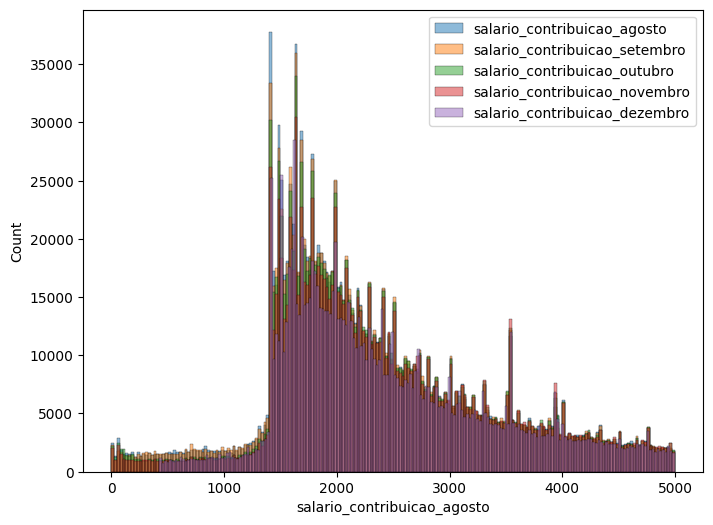

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

limsup = 5000
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_agosto", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_setembro", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_outubro", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_novembro", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_dezembro", limsup = limsup, ax = ax)

ax.legend(loc = "upper right")
plt.show()

Como podemos ver, o mês de dezembro em específico tem um limite inferior em torno de 400. De fato, os valores inferiores a 400 nos demais meses provavelmente dizem respeito a pagamentos proporcionais a dias de trabalho no mês de desligamento, já que são inferiores a um salário. De fato, ao considerar o último mês, mesmo esses valores tender a ter um piso inferior, dado a parcela final do décimo terceiro e possíveis gratificações/abonos de fim de ano.

Ainda assim, vemos um padrão muito similar entre os valores pagos no mês de dezembro e nos demais meses.

In [12]:
df_centrooeste_desligamento.columns = ["causa_afastamento1", "causa_afastamento2", "causa_afastamento3", "qtd_dias_afastamento"]
df_centrooeste_desligamento.head(3)

,causa_afastamento1,causa_afastamento2,causa_afastamento3,qtd_dias_afastamento
0,999,999,999,0
1,40,999,999,1
2,999,999,999,0


In [13]:
df_centrooeste_geographic.columns = ["distrito_sp", "bairro_sp", "bairro_fortaleza", "bairro_rj", "regioes_adm_df"]
df_centrooeste_geographic.head(3)

,distrito_sp,bairro_sp,bairro_fortaleza,bairro_rj,regioes_adm_df
0,999997,999997,999997,999997,999997
1,999997,999997,999997,999997,999997
2,999997,999997,999997,999997,999997


## Merging all columns into a single, clean dataset

#### Demographic

In [14]:
df_centrooeste_demographic.head(2)

,idade,faixa_etaria,sexo,raca,escolaridade,nacionalidade,ano_chegada,deficiente,tipo_deficiencia
0,20,3,1,2,7,10,1198,0,0
1,33,5,1,2,9,10,1198,0,0


In [15]:
# Substitui idades iguais a zero por np.nan para a fácil remoção dessas variáveis
df_centrooeste_demographic.loc[df_centrooeste_demographic["idade"] == 0, "idade"] = np.nan

In [16]:
df_centrooeste_demographic["idade"].unique()

array([20., 33., 30., 51., 28., 34., 21., 47., 58., 29., 40., 61., 39.,
       45., 23., 41., 27., 24., 26., 46., 38., 32., 43., 50., 48., 25.,
       35., 31., 54., 37., 52., 55., 74., 70., 44., 49., 42., 71., 22.,
       65., 62., 36., 17., 60., 64., 57., 66., 53., 68., 67., 59., 73.,
       63., 69., 56., 18., 19., 75., 78., 72., 80., 77., 82., 92., 95.,
       76., 79., 84., 81., 83., 85., 16., 86., 90., 87., 88., 89., 14.,
       91., 15., 93., 94., 96., nan])

In [17]:
df_centrooeste_demographic["ano_chegada"].unique()

array([1198])

In [18]:
df_centrooeste_demographic["nacionalidade"].unique()

array([10, 40, 54, 51, 26, 24, 63, 25, 70, 42, 44, 45, 28, 49, 21, 30, 41,
       39, 22, 35, 27, 47, 64, 36, 23, 80, 60, 52, 31, 46, 29, 62, 37, 55,
       38, 32, 61, 34, 53, 56, 48, 43])

In [19]:
# 1. Garante que a coluna de Nacionalidade seja numérica para não dar erro na comparação
df_centrooeste_demographic['nacionalidade_num'] = pd.to_numeric(df_centrooeste_demographic['nacionalidade'], errors='coerce')

# 2. Mapeamento das listas de códigos por Continente/Região
# Mantemos o Brasil isolado como baseline
brasil = [10, 20]

# América do Sul e Caribe (Latino-americanos costumam ter dinâmicas parecidas de migração)
america_sul_central = [21, 22, 23, 24, 25, 26, 27, 28, 29, 40, 48] 
# América do Norte
america_norte = [34, 36]
# Europa (incluindo Rússia)
europa = [30, 31, 32, 35, 37, 38, 39, 44, 45, 51]
# Ásia
asia = [41, 42, 43, 46, 47, 49, 59]
# África
africa = [60, 61, 62, 63, 64, 70]

# Define as condições de roteamento
condicoes = [
    df_centrooeste_demographic['nacionalidade_num'].isin(brasil),
    df_centrooeste_demographic['nacionalidade_num'].isin(america_sul_central),
    df_centrooeste_demographic['nacionalidade_num'].isin(america_norte),
    df_centrooeste_demographic['nacionalidade_num'].isin(europa),
    df_centrooeste_demographic['nacionalidade_num'].isin(asia),
    df_centrooeste_demographic['nacionalidade_num'].isin(africa)
]

# Define os nomes das categorias
categorias = [
    'Brasil',
    'America_Sul_Central',
    'America_Norte',
    'Europa',
    'Asia',
    'Africa'
]

# Aplica a vetorização. O que sobrar (50, 80, -1, NaN) cai em 'Outros_Ignorado'
df_centrooeste_demographic['continente_origem'] = np.select(condicoes, categorias, default='Outros_Ignorado')

# Converte para categoria para economizar memória (útil para sua base de milhões de linhas)
df_centrooeste_demographic['continente_origem'] = df_centrooeste_demographic['continente_origem'].astype('category')

# Verifica a distribuição final
print(df_centrooeste_demographic['continente_origem'].value_counts(dropna=False))

continente_origem
Brasil                 2433028
America_Sul_Central      11671
Outros_Ignorado           1031
Europa                     767
Asia                       694
Africa                     425
America_Norte              217
Name: count, dtype: int64


#### Company

In [20]:
df_centrooeste_company.head(3)

,cod_municipio,cod_municipio_trabalho,estado,cnae_atualizada,cnae_antiga,cnae_atualizada_granular,natureza_juridica,tamanho_estabelecimento,tipo_estabelecimento,tipo_estabelecimento_1,ibge_subsetor,simples_nacional,cadastro_especifico_inss,trabalho_local_da_sede
0,510340,999999,Cuiaba,6822,7032,6822600,2062,5,1,CNPJ,19,0,0,0
1,530010,999999,Brasilia,6550,6630,6550200,2054,5,1,CNPJ,18,0,0,0
2,530010,999999,Brasilia,4120,4521,4120400,2062,7,1,CNPJ,15,0,0,0


É interessante realizarmos a simplificação do Código CNAE das empresas para considerar uma classificação mais geral de suas funções. Para isso, consideramos as 21 classes já previstas pelo IBGE para a atividade de diferentes empresas. Para agrupar os códigos do CNAE acima nessas classes, consideramos os dois primeiros dígitos do código.

In [21]:
# Completa eventuais zero a esquerda que podem ter sido absorvidos pelo pandas ao considerar essa coluna como numérica
df_centrooeste_company['cnae_str'] = df_centrooeste_company['cnae_atualizada_granular'].astype(str).str.zfill(7)

# Extraímos a 'Divisão' (dois primeiros dígitos)
df_centrooeste_company['cnae_divisao'] = df_centrooeste_company['cnae_str'].str[:2].astype(int)

# Criamos as regras de mapeamento do IBGE para as 21 Seções (Letras de A a U)
condicoes_secao = [
    df_centrooeste_company['cnae_divisao'].between(1, 3),    # A: Agricultura, Pecuária
    df_centrooeste_company['cnae_divisao'].between(5, 9),    # B: Indústrias Extrativas
    df_centrooeste_company['cnae_divisao'].between(10, 33),  # C: Indústrias de Transformação
    df_centrooeste_company['cnae_divisao'] == 35,            # D: Eletricidade e Gás
    df_centrooeste_company['cnae_divisao'].between(36, 39),  # E: Água, Esgoto e Lixo
    df_centrooeste_company['cnae_divisao'].between(41, 43),  # F: Construção
    df_centrooeste_company['cnae_divisao'].between(45, 47),  # G: Comércio e Reparação de Veículos
    df_centrooeste_company['cnae_divisao'].between(49, 53),  # H: Transporte e Armazenagem
    df_centrooeste_company['cnae_divisao'].between(55, 56),  # I: Alojamento e Alimentação
    df_centrooeste_company['cnae_divisao'].between(58, 63),  # J: Informação e Comunicação
    df_centrooeste_company['cnae_divisao'].between(64, 66),  # K: Atividades Financeiras
    df_centrooeste_company['cnae_divisao'] == 68,            # L: Atividades Imobiliárias
    df_centrooeste_company['cnae_divisao'].between(69, 75),  # M: Ativ. Profissionais, Científicas e Técnicas
    df_centrooeste_company['cnae_divisao'].between(77, 82),  # N: Ativ. Administrativas e Serviços Complementares
    df_centrooeste_company['cnae_divisao'] == 84,            # O: Administração Pública
    df_centrooeste_company['cnae_divisao'] == 85,            # P: Educação
    df_centrooeste_company['cnae_divisao'].between(86, 88),  # Q: Saúde Humana e Serviços Sociais
    df_centrooeste_company['cnae_divisao'].between(90, 93),  # R: Artes, Cultura, Esporte e Recreação
    df_centrooeste_company['cnae_divisao'].between(94, 96),  # S: Outros Serviços
    df_centrooeste_company['cnae_divisao'] == 97,            # T: Serviços Domésticos
    df_centrooeste_company['cnae_divisao'] == 99             # U: Organismos Internacionais
]
letras_secao = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']

# Aplicamos o mapeamento
df_centrooeste_company['cnae_secao'] = np.select(condicoes_secao, letras_secao, default = 'Outros')

In [22]:
# Define a falta de natureza jurídica como dado faltante
df_centrooeste_company.loc[df_centrooeste_company['natureza_juridica'] == 9999, "natureza_juridica"] = np.nan

# Corrige a variável garantindo que seja uma string de 4 dígitos
df_centrooeste_company['natureza_juridica_str'] = df_centrooeste_company['natureza_juridica'].astype(str).str.zfill(4)

# Extrai apenas o primeiro dígito
df_centrooeste_company['natureza_juridica_primeiro_digito'] = df_centrooeste_company['natureza_juridica_str'].str[0]

# Cria o dicionário de mapeamento das macrocategorias
mapa_natureza_juridica = {
    '1': 'administracao_publica',
    '2': 'setor_privado',
    '3': 'terceiro_setor_sem_fins_lucrativos',
    '4': 'pessoa_fisica',
    '5': 'organizacoes_internacionais'
}

# Aplica o mapeamento para criar a nova coluna simplificada
df_centrooeste_company['setor_economico'] = df_centrooeste_company['natureza_juridica_primeiro_digito'].map(mapa_natureza_juridica)

['CNPJ' 'CNO' 'CAEPF']


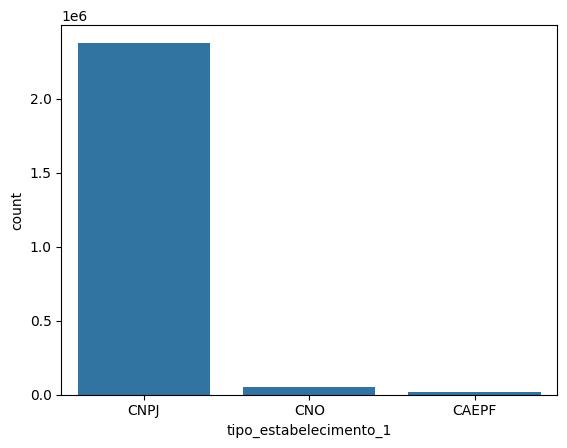

In [23]:
df_centrooeste_company["tipo_estabelecimento_1"] = df_centrooeste_company["tipo_estabelecimento_1"].str.strip()
print(df_centrooeste_company["tipo_estabelecimento_1"].unique())
sns.countplot(x = df_centrooeste_company["tipo_estabelecimento_1"])
plt.show()

Como podemos ver, o tipo de estabelecimento predominante na base é CNPJ. De fato, parece razoável removermos da base os demais títulos de empresa, de modo a forcarmos a análise exclusivamente em empresas representadas por um CNPJ.

In [24]:
df_centrooeste_company.head(3)

,cod_municipio,cod_municipio_trabalho,estado,cnae_atualizada,cnae_antiga,cnae_atualizada_granular,natureza_juridica,tamanho_estabelecimento,tipo_estabelecimento,tipo_estabelecimento_1,ibge_subsetor,simples_nacional,cadastro_especifico_inss,trabalho_local_da_sede,cnae_str,cnae_divisao,cnae_secao,natureza_juridica_str,natureza_juridica_primeiro_digito,setor_economico
0,510340,999999,Cuiaba,6822,7032,6822600,2062.0,5,1,CNPJ,19,0,0,0,6822600,68,L,2062.0,2,setor_privado
1,530010,999999,Brasilia,6550,6630,6550200,2054.0,5,1,CNPJ,18,0,0,0,6550200,65,K,2054.0,2,setor_privado
2,530010,999999,Brasilia,4120,4521,4120400,2062.0,7,1,CNPJ,15,0,0,0,4120400,41,F,2062.0,2,setor_privado


#### Vínculo

In [25]:
df_centrooeste_vinculo.head(3)

,ocupacao,tipo_vinculo,tipo_admissao,vinculo_ativo_3112,mes_admissao,mes_desligamento,motivo_desligamento,tempo_emprego,faixa_tempo_emprego,horas_semanais,faixa_hora_contratual,jornada_intermitente,jornada_parcial,vinculo_abandonado
0,317210,10,2,1,7,0,0,5.7,2,44,6,0,0,0
1,411010,10,0,0,0,5,11,15.6,4,44,6,0,0,0
2,514120,10,0,0,0,8,11,8.9,3,44,6,0,0,0


In [26]:
# Agrupa as ocupações segundo a Classificação Brasileira de Ocupações (CBO)

# Garante os 6 dígitos
df_centrooeste_vinculo['cbo_str'] = df_centrooeste_vinculo['ocupacao'].astype(str).str.zfill(6)
# Pega o primeiro dígito
df_centrooeste_vinculo['ocupacao_cbo'] = df_centrooeste_vinculo['cbo_str'].str[0]

# Mapeamento dos números para classes (dicionário)
mapa_cbo = {
    '0': 'Militares_Policiais',
    '1': 'Diretores_Gerentes',
    '2': 'Profissionais_Nivel_Superior',
    '3': 'Tecnicos_Nivel_Medio',
    '4': 'Servicos_Administrativos',
    '5': 'Servicos_e_Vendas',
    '6': 'Agropecuaria',
    '7': 'Industria_Producao',
    '8': 'Industria_Producao', # 7 e 8 se misturam na indústria
    '9': 'Manutencao_Reparacao'
}

df_centrooeste_vinculo['grupo_ocupacao_cbo'] = df_centrooeste_vinculo['ocupacao_cbo'].map(mapa_cbo)

In [27]:
# Garante que a variável seja tratada como número para a comparação
df_centrooeste_vinculo['tipo_vinculo_num'] = pd.to_numeric(df_centrooeste_vinculo['tipo_vinculo'], errors = 'coerce')

# Listas com os códigos exatos do seu dicionário
clt_indeterminado = [10, 15, 20, 25]
prazo_determinado = [50, 55, 60, 65, 70, 75, 90, 95]
setor_publico = [30, 31, 35, 96, 97]

# Regras de roteamento
condicoes = [
    df_centrooeste_vinculo['tipo_vinculo_num'].isin(clt_indeterminado),
    df_centrooeste_vinculo['tipo_vinculo_num'].isin(prazo_determinado),
    df_centrooeste_vinculo['tipo_vinculo_num'].isin(setor_publico)
]

categorias = [
    'CLT_Indeterminado', # Contrato sem prazo para acabar
    'Prazo_Determinado', # Contrato com prazo determinado (temporários e aprendizes)
    'Setor_Publico' # Setor Público e Estatutários
]

# O que for 40, 80, -1 ou nulo cairá automaticamente em 'Outros'
df_centrooeste_vinculo['vinculo_agrupado'] = np.select(condicoes, categorias, default='Outros')

In [28]:
# Garante que a coluna seja interpretada como numérica para evitar erros de tipagem ('1' vs 1)
df_centrooeste_vinculo['tipo_admissao_num'] = pd.to_numeric(df_centrooeste_vinculo['tipo_admissao'], errors='coerce')

# Define as condições baseadas nos códigos do seu dicionário
condicoes = [
    df_centrooeste_vinculo['tipo_admissao_num'] == 0,           # Estoque (Não admitido no ano)
    df_centrooeste_vinculo['tipo_admissao_num'].isin([1, 2]),   # Primeiro Emprego e Reemprego
    df_centrooeste_vinculo['tipo_admissao_num'].isin([3, 4])    # Transferências com e sem ônus
]

# Define os nomes das novas macrocategorias correspondentes
categorias = [
    'Estoque_Anos_Anteriores',
    'Admissoes_Mercado',
    'Transferencias_Internas'
]

# Aplica a vetorização. Tudo que não for 0, 1, 2, 3 ou 4 (ou seja, de 5 a 10, -1 ou nulo) 
# cairá automaticamente no grupo 'Especiais_Outros'
df_centrooeste_vinculo['admissao_agrupada'] = np.select(condicoes, categorias, default='Especiais_Outros')

In [29]:
# Substitui horas semanais registradas como 99 por np.nan para que seja mais fácil a remoção dessas observações em seguida
df_centrooeste_vinculo['horas_semanais'] = df_centrooeste_vinculo['horas_semanais'].replace(99, np.nan)

In [30]:
# Agrupa "jornada_intermitente" e "jornada_parcial" em uma única variável categórica

# Regras: Se for 1 na coluna Parcial, vira 'Parcial'. Se for 1 na Intermitente, vira 'Intermitente'.
# Se for 0 em ambas, é a linha de base ('Integral').
condicoes = [
    df_centrooeste_vinculo['jornada_parcial'] == 1,
    df_centrooeste_vinculo['jornada_intermitente'] == 1
]

categorias = [
    'Jornada_Parcial',
    'Jornada_Intermitente'
]

# Cria a variável consolidada
df_centrooeste_vinculo['regime_jornada'] = np.select(condicoes, categorias, default='Jornada_Integral')

In [31]:
df_centrooeste_vinculo.head(3)

,ocupacao,tipo_vinculo,tipo_admissao,vinculo_ativo_3112,mes_admissao,mes_desligamento,motivo_desligamento,tempo_emprego,faixa_tempo_emprego,horas_semanais,...,jornada_parcial,vinculo_abandonado,cbo_str,ocupacao_cbo,grupo_ocupacao_cbo,tipo_vinculo_num,vinculo_agrupado,tipo_admissao_num,admissao_agrupada,regime_jornada
0,317210,10,2,1,7,0,0,5.7,2,44.0,...,0,0,317210,3,Tecnicos_Nivel_Medio,10,CLT_Indeterminado,2,Admissoes_Mercado,Jornada_Integral
1,411010,10,0,0,0,5,11,15.6,4,44.0,...,0,0,411010,4,Servicos_Administrativos,10,CLT_Indeterminado,0,Estoque_Anos_Anteriores,Jornada_Integral
2,514120,10,0,0,0,8,11,8.9,3,44.0,...,0,0,514120,5,Servicos_e_Vendas,10,CLT_Indeterminado,0,Estoque_Anos_Anteriores,Jornada_Integral


#### Remuneração

In [32]:
df_centrooeste_remuneracao.head(2)

,remuneracao_media_nominal,remuneracao_media_sm,salario_contribuicao_janeiro,salario_contribuicao_fevereiro,salario_contribuicao_marco,salario_contribuicao_abril,salario_contribuicao_maio,salario_contribuicao_junho,salario_contribuicao_julho,salario_contribuicao_agosto,salario_contribuicao_setembro,salario_contribuicao_outubro,salario_contribuicao_novembro,salario_contribuicao_dezembro
0,2192.04,1.55,0.00,0.00,0.00,0.00,0.0,0.0,1682.23,2294.0,2294.0,2294.0,2294.0,2294.0
1,1684.41,1.19,1781.77,1799.59,2152.28,1004.01,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN


#### Desligamento

In [33]:
df_centrooeste_desligamento.head(2)

,causa_afastamento1,causa_afastamento2,causa_afastamento3,qtd_dias_afastamento
0,999,999,999,0
1,40,999,999,1


In [34]:
# "deficiencia" já incluso em "tipo_deficiencia" e variável "ano_chegada" igual para todos os trabalhadores
# Ao invés de considerar a nacionalidade do funcionário, utilizamos seu continente de origem para simplificar o problema
df_centrooeste_demographic_filtered = df_centrooeste_demographic.loc[: , ["idade", "sexo",
                                                                          "raca", "escolaridade", "continente_origem",
                                                                          "tipo_deficiencia"]]
# "cod_municipio" e "cod_municipio_trabalho" representam muitos valores distintos e categóricos. Inviável para modelagem
# A natureza jurídica é muito granular. Agrupamos na classe geral da empresa a partir do seu código, extraindo o setor econômico
# ibge_subsetor consiste em uma categorização mais antiga da atividade da empresa. Removemos em prol do uso de cnae_secao
# simples_nacional removido pois todas as observações tem o mesmo valor 
# cadastro_especifico_inss tem forte relação com "tipo_estabelecimento_1" e já foi substituído. Desconsideramos
df_centrooeste_company_filtered = df_centrooeste_company.loc[:, ["estado", "cnae_secao", "setor_economico", "tamanho_estabelecimento",
                                                                 "tipo_estabelecimento_1", "trabalho_local_da_sede"]]
# ocupacao tem muitas categorias. Sendo assim, substituimos pela classificação geral do trabalho segundo a CBO
# tipo_admissao foi agrupado em três grandes classes, sendo o estoque dos anos anteriores (admitido antes do ano atual),
# admissoes mercado (contratação clássica via processo seletivo), transferências internas (com e sem ônus) e casos especiais ou públicos
# Tendo o número de horas semanais, não temos a necessidade de considerar a faixa de horas contratuais
# Jornada parcial, intermitente ou integral reduzidas à variável regime_jornada
df_centrooeste_vinculo_filtered = df_centrooeste_vinculo.loc[:, ["grupo_ocupacao_cbo", "vinculo_agrupado", "admissao_agrupada",
                                                                 "mes_admissao", "motivo_desligamento", "tempo_emprego",
                                                                 "horas_semanais", "regime_jornada", "vinculo_abandonado"]]
# Por simplicidade da análise, utiliza apenas a remuneração média recebida ao longo do ano.
# A presença de valores nulos em decorrência do desligamento do funcionário em um determinado mês podem levar
# à inclusão de vieses completamente não relacionados ao salário em si, mas confundidos com o mês de desligamento pelo modelo
# Tratando apenas o ganho médio base mensal do funcionário, temos uma melhor forma de modelar o fator salário
df_centrooeste_remuneracao_filtered = df_centrooeste_remuneracao.loc[:, ["remuneracao_media_nominal"]]
# Parece razoável modelar apenas a quantidade numérica de dias que o funcionário ficou afastado ao longo do ano
# A priori, espera-se que o desligamento tenha forte relação com essa variável
df_centrooeste_desligamento_filtered = df_centrooeste_desligamento.loc[:, ["qtd_dias_afastamento"]]

# Desconsideramos completamente as granularidades proporcionadas pelas variáveis em df_centrooeste_geographic na modelagem dos dados

Os DataFrames filtrados processados acima contém todas as informações mais interessantes para uma possível modelagem do tempo de empregabilidade de funcionários desde suas contratações. Nos resta filtrar algumas linhas observadas com valores faltantes ou relações que não fazem muito sentido para a análise. Por exemplo, dada a alta discrepância entre estabelecimentos com CNPJ em decorrência de estabelecimentos com CNO ou CAEPF, simplesmente desconsideramos todas as observações com esses dois últimos tipos da análise.

In [35]:
df_centrooeste_final = pd.concat([
    df_centrooeste_demographic_filtered,
    df_centrooeste_company_filtered,
    df_centrooeste_vinculo_filtered,
    df_centrooeste_remuneracao_filtered,
    df_centrooeste_desligamento_filtered], axis = 1)
df_centrooeste_final.head(3)

,idade,sexo,raca,escolaridade,continente_origem,tipo_deficiencia,estado,cnae_secao,setor_economico,tamanho_estabelecimento,...,vinculo_agrupado,admissao_agrupada,mes_admissao,motivo_desligamento,tempo_emprego,horas_semanais,regime_jornada,vinculo_abandonado,remuneracao_media_nominal,qtd_dias_afastamento
0,20.0,1,2,7,Brasil,0,Cuiaba,L,setor_privado,5,...,CLT_Indeterminado,Admissoes_Mercado,7,0,5.7,44.0,Jornada_Integral,0,2192.04,0
1,33.0,1,2,9,Brasil,0,Brasilia,K,setor_privado,5,...,CLT_Indeterminado,Estoque_Anos_Anteriores,0,11,15.6,44.0,Jornada_Integral,0,1684.41,1
2,30.0,1,8,6,Brasil,0,Brasilia,F,setor_privado,7,...,CLT_Indeterminado,Estoque_Anos_Anteriores,0,11,8.9,44.0,Jornada_Integral,0,1761.08,0


In [36]:
df_centrooeste_final.columns

Index(['idade', 'sexo', 'raca', 'escolaridade', 'continente_origem',
       'tipo_deficiencia', 'estado', 'cnae_secao', 'setor_economico',
       'tamanho_estabelecimento', 'tipo_estabelecimento_1',
       'trabalho_local_da_sede', 'grupo_ocupacao_cbo', 'vinculo_agrupado',
       'admissao_agrupada', 'mes_admissao', 'motivo_desligamento',
       'tempo_emprego', 'horas_semanais', 'regime_jornada',
       'vinculo_abandonado', 'remuneracao_media_nominal',
       'qtd_dias_afastamento'],
      dtype='object')

In [37]:
# df_centrooeste_final.loc[
#     df_centrooeste_final["vinculo_abandonado"] == 1, ['motivo_desligamento', 'salario_contribuicao_janeiro',
#        'salario_contribuicao_fevereiro', 'salario_contribuicao_marco',
#        'salario_contribuicao_abril', 'salario_contribuicao_maio',
#        'salario_contribuicao_junho', 'salario_contribuicao_julho',
#        'salario_contribuicao_agosto', 'salario_contribuicao_setembro',
#        'salario_contribuicao_outubro', 'salario_contribuicao_novembro',
#        'salario_contribuicao_dezembro']
# ]

In [38]:
df_centrooeste_final = pd.concat([
    df_centrooeste_demographic_filtered,
    df_centrooeste_company_filtered,
    df_centrooeste_vinculo_filtered,
    df_centrooeste_remuneracao_filtered,
    df_centrooeste_desligamento_filtered], axis = 1)

df_centrooeste_final = df_centrooeste_final.loc[ df_centrooeste_final["tipo_estabelecimento_1"] == "CNPJ" , : ]
# Mantendo apenas empresas com CNPJ, não tem necessidade em mantermos essa coluna para o tipo do estabelecimento
df_centrooeste_final = df_centrooeste_final.drop(columns = "tipo_estabelecimento_1")

# Removendo todos os funcionários registrados erroneamente (vínculos fantasma)
df_centrooeste_final = df_centrooeste_final.loc[ df_centrooeste_final["vinculo_abandonado"] == 0 , : ]
df_centrooeste_final = df_centrooeste_final.drop(columns = "vinculo_abandonado")

In [39]:
# Remove todas as linhas com observações faltantes relacionadas à quantidade de horas semanais
df_centrooeste_final.isna().sum()

idade                            0
sexo                             0
raca                             0
escolaridade                     0
continente_origem                0
tipo_deficiencia                 0
estado                           0
cnae_secao                       0
setor_economico                  0
tamanho_estabelecimento          0
trabalho_local_da_sede           0
grupo_ocupacao_cbo               0
vinculo_agrupado                 0
admissao_agrupada                0
mes_admissao                     0
motivo_desligamento              0
tempo_emprego                    0
horas_semanais               80840
regime_jornada                   0
remuneracao_media_nominal        0
qtd_dias_afastamento             0
dtype: int64

In [40]:
# Remove todas as linhas com observações faltantes relacionadas à quantidade de horas semanais
df_centrooeste_final = df_centrooeste_final.dropna()

if(not "regiao" in df_centrooeste_final.columns):
    df_centrooeste_final.insert(0, "regiao", "Centro-Oeste")

print("Dimensão dos dados do Centro-Oeste processados: {}".format(df_centrooeste_final.shape))
df_centrooeste_final.head()

Dimensão dos dados do Centro-Oeste processados: (2255403, 22)


,regiao,idade,sexo,raca,escolaridade,continente_origem,tipo_deficiencia,estado,cnae_secao,setor_economico,...,grupo_ocupacao_cbo,vinculo_agrupado,admissao_agrupada,mes_admissao,motivo_desligamento,tempo_emprego,horas_semanais,regime_jornada,remuneracao_media_nominal,qtd_dias_afastamento
0,Centro-Oeste,20.0,1,2,7,Brasil,0,Cuiaba,L,setor_privado,...,Tecnicos_Nivel_Medio,CLT_Indeterminado,Admissoes_Mercado,7,0,5.7,44.0,Jornada_Integral,2192.04,0
1,Centro-Oeste,33.0,1,2,9,Brasil,0,Brasilia,K,setor_privado,...,Servicos_Administrativos,CLT_Indeterminado,Estoque_Anos_Anteriores,0,11,15.6,44.0,Jornada_Integral,1684.41,1
2,Centro-Oeste,30.0,1,8,6,Brasil,0,Brasilia,F,setor_privado,...,Servicos_e_Vendas,CLT_Indeterminado,Estoque_Anos_Anteriores,0,11,8.9,44.0,Jornada_Integral,1761.08,0
3,Centro-Oeste,51.0,2,2,9,Brasil,0,Brasilia,H,setor_privado,...,Servicos_Administrativos,CLT_Indeterminado,Transferencias_Internas,8,0,4.5,40.0,Jornada_Integral,7090.96,0
4,Centro-Oeste,28.0,2,8,9,Brasil,0,Cuiaba,M,setor_privado,...,Profissionais_Nivel_Superior,CLT_Indeterminado,Estoque_Anos_Anteriores,0,0,43.0,44.0,Jornada_Integral,2157.32,120


In [41]:
def optimize_memory_categories_rais(df):
    """
    Converte os tipos de dados do DataFrame da RAIS para otimizar o uso de memória.
    """
    
    # Variáveis estritamente categóricas (Baixa cardinalidade)
    # Convertê-las de object/int64 para 'category' salva muita memória e acelera agrupamentos.
    colunas_categoricas = [
        'regiao', 'sexo', 'raca', 'escolaridade', 'nacionalidade', 
        'tipo_deficiencia', 'estado', 'cnae_secao', 'setor_economico', 
        'tamanho_estabelecimento', 'grupo_ocupacao_cbo', 'vinculo_agrupado', 
        'mes_admissao', 'motivo_desligamento', 'regime_jornada', 'admissao_agrupada'
    ]
    
    for col in colunas_categoricas:
        if(col in df.columns):
            df[col] = df[col].astype('category')

    # Variáveis contínuas (Tempo, Dinheiro, Idade)
    # Por padrão, o Pandas aloca float64 (que possui precisão astronômica, desnecessária aqui).
    # Reduzir para float32 corta o peso dessas colunas pela metade sem perder precisão analítica.
    colunas_float = [
        'idade', 'tempo_emprego', 'horas_semanais', 'remuneracao_media_nominal'
    ]
    
    for col in colunas_float:
        if(col in df.columns):
            df[col] = df[col].astype('float32')
            
    # Variáveis de contagem ou numéricas inteiras
    # qtd_dias_afastamento varia de 0 a 365, cabe perfeitamente em um inteiro de 16 bits.
    if('qtd_dias_afastamento' in df.columns):
        df['qtd_dias_afastamento'] = df['qtd_dias_afastamento'].astype('int16')

    # 4. Variáveis booleanas (0 e 1)
    # trabalho_local_da_sede já está listada como uint8 (Unsigned Integer de 8 bits), 
    # o que já é a representação mais otimizada possível (ocupa apenas 1 byte por linha).
    # Opcionalmente, pode ser convertida para bool explícito:
    if('trabalho_local_da_sede' in df.columns):
        df['trabalho_local_da_sede'] = df['trabalho_local_da_sede'].astype(bool)

    return df

Embora tenhamos uma base completamente processada, vejamos quanto esse DataFrame ocupa na memória RAM com o comando abaixo

In [42]:
df_centrooeste_final.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 2255403 entries, 0 to 2447831
Data columns (total 22 columns):
 #   Column                     Dtype   
---  ------                     -----   
 0   regiao                     object  
 1   idade                      float64 
 2   sexo                       int64   
 3   raca                       int64   
 4   escolaridade               int64   
 5   continente_origem          category
 6   tipo_deficiencia           int64   
 7   estado                     object  
 8   cnae_secao                 object  
 9   setor_economico            object  
 10  tamanho_estabelecimento    int64   
 11  trabalho_local_da_sede     uint8   
 12  grupo_ocupacao_cbo         object  
 13  vinculo_agrupado           object  
 14  admissao_agrupada          object  
 15  mes_admissao               int64   
 16  motivo_desligamento        int64   
 17  tempo_emprego              float64 
 18  horas_semanais             float64 
 19  regime_jornada            

Temos um total de 1.4 GB ocupados. Isso se dá devido à alta precisão das variáveis numéricas (int64 e float64), assim como a repetição desnecessária de categorias em colunas do tipo "object", quando nada verdade se tratam de apenas algumas classes. Para mitigar estes problemas, utilizamos a função optimize_memory_categories para nos auxiliar neste processo.

In [43]:
# Aplicando a função na sua base do Centro-Oeste
df_centrooeste_final = optimize_memory_categories_rais(df_centrooeste_final)

# Verificando a redução de memória (em Megabytes)
df_centrooeste_final.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 2255403 entries, 0 to 2447831
Data columns (total 22 columns):
 #   Column                     Dtype   
---  ------                     -----   
 0   regiao                     category
 1   idade                      float32 
 2   sexo                       category
 3   raca                       category
 4   escolaridade               category
 5   continente_origem          category
 6   tipo_deficiencia           category
 7   estado                     category
 8   cnae_secao                 category
 9   setor_economico            category
 10  tamanho_estabelecimento    category
 11  trabalho_local_da_sede     bool    
 12  grupo_ocupacao_cbo         category
 13  vinculo_agrupado           category
 14  admissao_agrupada          category
 15  mes_admissao               category
 16  motivo_desligamento        category
 17  tempo_emprego              float32 
 18  horas_semanais             float32 
 19  regime_jornada            

In [44]:
1024*1.4 / 92.5

15.498378378378378

Veja que reduzimos uma base de dados de 1.6GB para apenas 92.5 MB, o que corresponde a uma diminuição de aproximadamente 15.5 vezes o tamanho original.

Finalmente, após o processamento dos dados do Centro-Oeste, temos um total de 24 colunas a serem consideradas na etapa de modelagem, as quais já estão devidamente otimizadas para ocupar o mínimo de memória possível. Agora, nos resta apenas automatizar o processo de pré-processamento de dados realizado acima para que possamos processar as bases de todas as regiões e incluí-las em uma mesma base de dados gigante.

Na função abaixo, reimplementamos todo o pipeline desenvolvido com cuidado acima para um DataFrame arbitrário e retornamos a matriz de dados já processada, pronta para o salvamento.

In [45]:
def preprocess_demographic(df_demographic):
    df_demographic.loc[df_demographic["idade"] == 0, "idade"] = np.nan
    df_demographic['nacionalidade_num'] = pd.to_numeric(df_demographic['nacionalidade'], errors='coerce')
    brasil = [10, 20]
    america_sul_central = [21, 22, 23, 24, 25, 26, 27, 28, 29, 40, 48] 
    america_norte = [34, 36]
    europa = [30, 31, 32, 35, 37, 38, 39, 44, 45, 51]
    asia = [41, 42, 43, 46, 47, 49, 59]
    africa = [60, 61, 62, 63, 64, 70]
    condicoes = [
        df_demographic['nacionalidade_num'].isin(brasil),
        df_demographic['nacionalidade_num'].isin(america_sul_central),
        df_demographic['nacionalidade_num'].isin(america_norte),
        df_demographic['nacionalidade_num'].isin(europa),
        df_demographic['nacionalidade_num'].isin(asia),
        df_demographic['nacionalidade_num'].isin(africa)
    ]
    categorias = [
        'Brasil',
        'America_Sul_Central',
        'America_Norte',
        'Europa',
        'Asia',
        'Africa'
    ]
    df_demographic['continente_origem'] = np.select(condicoes, categorias, default='Outros_Ignorado')
    df_demographic['continente_origem'] = df_demographic['continente_origem'].astype('category')
    return df_demographic

In [46]:
def preprocess_company(df_company):
    df_company['cnae_str'] = df_company['cnae_atualizada_granular'].astype(str).str.zfill(7)
    df_company['cnae_divisao'] = df_company['cnae_str'].str[:2].astype(int)
    condicoes_secao = [
        df_company['cnae_divisao'].between(1, 3),    # A: Agricultura, Pecuária
        df_company['cnae_divisao'].between(5, 9),    # B: Indústrias Extrativas
        df_company['cnae_divisao'].between(10, 33),  # C: Indústrias de Transformação
        df_company['cnae_divisao'] == 35,            # D: Eletricidade e Gás
        df_company['cnae_divisao'].between(36, 39),  # E: Água, Esgoto e Lixo
        df_company['cnae_divisao'].between(41, 43),  # F: Construção
        df_company['cnae_divisao'].between(45, 47),  # G: Comércio e Reparação de Veículos
        df_company['cnae_divisao'].between(49, 53),  # H: Transporte e Armazenagem
        df_company['cnae_divisao'].between(55, 56),  # I: Alojamento e Alimentação
        df_company['cnae_divisao'].between(58, 63),  # J: Informação e Comunicação
        df_company['cnae_divisao'].between(64, 66),  # K: Atividades Financeiras
        df_company['cnae_divisao'] == 68,            # L: Atividades Imobiliárias
        df_company['cnae_divisao'].between(69, 75),  # M: Ativ. Profissionais, Científicas e Técnicas
        df_company['cnae_divisao'].between(77, 82),  # N: Ativ. Administrativas e Serviços Complementares
        df_company['cnae_divisao'] == 84,            # O: Administração Pública
        df_company['cnae_divisao'] == 85,            # P: Educação
        df_company['cnae_divisao'].between(86, 88),  # Q: Saúde Humana e Serviços Sociais
        df_company['cnae_divisao'].between(90, 93),  # R: Artes, Cultura, Esporte e Recreação
        df_company['cnae_divisao'].between(94, 96),  # S: Outros Serviços
        df_company['cnae_divisao'] == 97,            # T: Serviços Domésticos
        df_company['cnae_divisao'] == 99             # U: Organismos Internacionais
    ]
    letras_secao = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']
    df_company['cnae_secao'] = np.select(condicoes_secao, letras_secao, default = 'Outros')
    df_company.loc[df_company['natureza_juridica'] == 9999, "natureza_juridica"] = np.nan
    df_company['natureza_juridica_str'] = df_company['natureza_juridica'].astype(str).str.zfill(4)
    df_company['natureza_juridica_primeiro_digito'] = df_company['natureza_juridica_str'].str[0]
    mapa_natureza_juridica = {
        '1': 'administracao_publica',
        '2': 'setor_privado',
        '3': 'terceiro_setor_sem_fins_lucrativos',
        '4': 'pessoa_fisica',
        '5': 'organizacoes_internacionais'
    }
    df_company['setor_economico'] = df_company['natureza_juridica_primeiro_digito'].map(mapa_natureza_juridica)
    df_company["tipo_estabelecimento_1"] = df_company["tipo_estabelecimento_1"].str.strip()
    return df_company

In [47]:
def preprocess_vinculo(df_vinculo):
    df_vinculo['cbo_str'] = df_vinculo['ocupacao'].astype(str).str.zfill(6)
    df_vinculo['ocupacao_cbo'] = df_vinculo['cbo_str'].str[0]
    mapa_cbo = {
        '0': 'Militares_Policiais',
        '1': 'Diretores_Gerentes',
        '2': 'Profissionais_Nivel_Superior',
        '3': 'Tecnicos_Nivel_Medio',
        '4': 'Servicos_Administrativos',
        '5': 'Servicos_e_Vendas',
        '6': 'Agropecuaria',
        '7': 'Industria_Producao',
        '8': 'Industria_Producao', # 7 e 8 se misturam na indústria
        '9': 'Manutencao_Reparacao'
    }
    df_vinculo['grupo_ocupacao_cbo'] = df_vinculo['ocupacao_cbo'].map(mapa_cbo)
    
    df_vinculo['tipo_vinculo_num'] = pd.to_numeric(df_vinculo['tipo_vinculo'], errors = 'coerce')
    
    clt_indeterminado = [10, 15, 20, 25]
    prazo_determinado = [50, 55, 60, 65, 70, 75, 90, 95]
    setor_publico = [30, 31, 35, 96, 97]
    
    condicoes = [
        df_vinculo['tipo_vinculo_num'].isin(clt_indeterminado),
        df_vinculo['tipo_vinculo_num'].isin(prazo_determinado),
        df_vinculo['tipo_vinculo_num'].isin(setor_publico)
    ]
    
    categorias = [
        'CLT_Indeterminado', # Contrato sem prazo para acabar
        'Prazo_Determinado', # Contrato com prazo determinado (temporários e aprendizes)
        'Setor_Publico' # Setor Público e Estatutários
    ]    
    df_vinculo['vinculo_agrupado'] = np.select(condicoes, categorias, default='Outros')

    
    df_vinculo['tipo_admissao_num'] = pd.to_numeric(df_vinculo['tipo_admissao'], errors='coerce')
    condicoes = [
        df_vinculo['tipo_admissao_num'] == 0,           # Estoque (Não admitido no ano)
        df_vinculo['tipo_admissao_num'].isin([1, 2]),   # Primeiro Emprego e Reemprego
        df_vinculo['tipo_admissao_num'].isin([3, 4])    # Transferências com e sem ônus
    ]
    categorias = [
        'Estoque_Anos_Anteriores',
        'Admissoes_Mercado',
        'Transferencias_Internas'
    ]
    df_vinculo['admissao_agrupada'] = np.select(condicoes, categorias, default='Especiais_Outros')
    df_vinculo['horas_semanais'] = df_vinculo['horas_semanais'].replace(99, np.nan)
    condicoes = [
        df_vinculo['jornada_parcial'] == 1,
        df_vinculo['jornada_intermitente'] == 1
    ]
    categorias = [
        'Jornada_Parcial',
        'Jornada_Intermitente'
    ]
    df_vinculo['regime_jornada'] = np.select(condicoes, categorias, default='Jornada_Integral')

    return df_vinculo

In [48]:
def preprocess_region(df, nome_regiao):
    new_column_names = ["Bairros.SP", "Bairros.Fortaleza", "Bairros.RJ",
                        "Causa.Afastamento.1", "Causa.Afastamento.2", "Causa.Afastamento.3",
                        "Motivo.Desligamento", "CBO.Ocupação.2002", "CNAE.2.0.Classe", "CNAE.95.Classe",
                        "Distritos.SP", "Vínculo.Ativo.31.12",
                        "Faixa.Etária", "Faixa.Remun.Média..SM.", "Faixa.Hora.Contrat", "Faixa.Remun.Dezem..SM.",
                        "Faixa.Tempo.Emprego", "Escolaridade.após.2005",
                        "Qtd.Hora.Contr", "Idade", "Ind.CEI.Vinculado",
                        "Ind.Simples", "Mês.Admissão", "Mês.Desligamento",
                        "Mun.Trab", "Município", "Nacionalidade", "Natureza.Jurídica",
                        "Ind.Portador.Defic", "Qtd.Dias.Afastamento", "Raça.Cor",
                        "Regiões.Adm.DF", "Vl.Remun.Dezembro.Nom",
                        "Vl.Remun.Dezembro..SM.", "Vl.Remun.Média.Nom", "Vl.Remun.Média..SM.",
                        "CNAE.2.0.Subclasse", "Sexo.Trabalhador", "Tamanho.Estabelecimento", "Tempo.Emprego",
                        "Tipo.Admissão", "Tipo.Estab", "Tipo.Estab.1", "Tipo.Defic",
                        "Tipo.Vínculo", "IBGE.Subsetor",
                        "Vl.Rem.Janeiro.SC", "Vl.Rem.Fevereiro.SC", "Vl.Rem.Março.SC", "Vl.Rem.Abril.SC",
                        "Vl.Rem.Maio.SC", "Vl.Rem.Junho.SC", "Vl.Rem.Julho.SC", "Vl.Rem.Agosto.SC",
                        "Vl.Rem.Setembro.SC", "Vl.Rem.Outubro.SC", "Vl.Rem.Novembro.SC", "Ano.Chegada.Brasil",
                        "Ind.Trab.Intermitente", "Ind.Trab.Parcial", "Ind.Vinc.Abandonado", "Estado"]
    df.columns = new_column_names
    
    demographic_variables = ["Idade", "Faixa.Etária", "Sexo.Trabalhador", "Raça.Cor", "Escolaridade.após.2005",
                             "Nacionalidade", "Ano.Chegada.Brasil", "Ind.Portador.Defic", "Tipo.Defic"]
    company_variables = ["Município", "Mun.Trab", "Estado", "CNAE.2.0.Classe", "CNAE.95.Classe", "CNAE.2.0.Subclasse",
                         "Natureza.Jurídica", "Tamanho.Estabelecimento", "Tipo.Estab", "Tipo.Estab.1", "IBGE.Subsetor",
                         "Ind.Simples", "Ind.CEI.Vinculado"]
    vinculo_variables = ["CBO.Ocupação.2002", "Tipo.Vínculo", "Tipo.Admissão", "Vínculo.Ativo.31.12",
                         "Mês.Admissão", "Mês.Desligamento", "Motivo.Desligamento", "Tempo.Emprego", "Faixa.Tempo.Emprego",
                         "Qtd.Hora.Contr", "Faixa.Hora.Contrat", "Ind.Trab.Intermitente", "Ind.Trab.Parcial", "Ind.Vinc.Abandonado"]
    remuneracao_variables = ["Vl.Remun.Média.Nom", "Vl.Remun.Média..SM.",
                             "Vl.Rem.Janeiro.SC", "Vl.Rem.Fevereiro.SC", 
                             "Vl.Rem.Março.SC", "Vl.Rem.Abril.SC",
                             "Vl.Rem.Maio.SC", "Vl.Rem.Junho.SC",
                             "Vl.Rem.Julho.SC", "Vl.Rem.Agosto.SC",
                             "Vl.Rem.Setembro.SC", "Vl.Rem.Outubro.SC",
                             "Vl.Rem.Novembro.SC", "Vl.Remun.Dezembro.Nom"]
    desligamento_variables = ["Causa.Afastamento.1", "Causa.Afastamento.2", "Causa.Afastamento.3",
                              "Qtd.Dias.Afastamento"]
    
    df_demographic = df.loc[:, demographic_variables]
    df_company = df.loc[:, company_variables]
    df_vinculo = df.loc[:, vinculo_variables]
    df_remuneracao = df.loc[:, remuneracao_variables]
    df_desligamento = df.loc[:, desligamento_variables]

    # Demographic
    df_demographic.columns = ["idade", "faixa_etaria", "sexo", "raca", "escolaridade", "nacionalidade", "ano_chegada", "deficiente", "tipo_deficiencia"]
    # Company
    df_company.columns = ["cod_municipio", "cod_municipio_trabalho", "estado", "cnae_atualizada", "cnae_antiga",
                          "cnae_atualizada_granular", "natureza_juridica", "tamanho_estabelecimento", "tipo_estabelecimento",
                          "tipo_estabelecimento_1", "ibge_subsetor", "simples_nacional", "cadastro_especifico_inss"]
    df_company["trabalho_local_da_sede"] = (df_company["cod_municipio"] == df_company["cod_municipio_trabalho"]).astype("uint8")
    # Vínculo
    df_vinculo.columns = ["ocupacao", "tipo_vinculo", "tipo_admissao", "vinculo_ativo_3112",
                          "mes_admissao", "mes_desligamento", "motivo_desligamento", "tempo_emprego", "faixa_tempo_emprego",
                          "horas_semanais", "faixa_hora_contratual", "jornada_intermitente", "jornada_parcial", "vinculo_abandonado"]
    df_remuneracao.columns = ["remuneracao_media_nominal", "remuneracao_media_sm",
                              "salario_contribuicao_janeiro", "salario_contribuicao_fevereiro",
                              "salario_contribuicao_marco", "salario_contribuicao_abril",
                              "salario_contribuicao_maio", "salario_contribuicao_junho",
                              "salario_contribuicao_julho", "salario_contribuicao_agosto",
                              "salario_contribuicao_setembro", "salario_contribuicao_outubro",
                              "salario_contribuicao_novembro", "salario_contribuicao_dezembro"]
    df_desligamento.columns = ["causa_afastamento1", "causa_afastamento2", "causa_afastamento3", "qtd_dias_afastamento"]

    df_demographic = preprocess_demographic(df_demographic)
    df_company = preprocess_company(df_company)
    df_vinculo = preprocess_vinculo(df_vinculo)
    
    # "deficiencia" já incluso em "tipo_deficiencia" e variável "ano_chegada" igual para todos os trabalhadores
    # Ao invés de considerar a nacionalidade do funcionário, utilizamos seu continente de origem para simplificar o problema
    df_demographic_filtered = df_demographic.loc[: , ["idade", "sexo",
                                                      "raca", "escolaridade", "continente_origem",
                                                      "tipo_deficiencia"]]
    # "cod_municipio" e "cod_municipio_trabalho" representam muitos valores distintos e categóricos. Inviável para modelagem
    # A natureza jurídica é muito granular. Agrupamos na classe geral da empresa a partir do seu código, extraindo o setor econômico
    # ibge_subsetor consiste em uma categorização mais antiga da atividade da empresa. Removemos em prol do uso de cnae_secao
    # simples_nacional removido pois todas as observações tem o mesmo valor 
    # cadastro_especifico_inss tem forte relação com "tipo_estabelecimento_1" e já foi substituído. Desconsideramos
    df_company_filtered = df_company.loc[:, ["estado", "cnae_secao", "setor_economico", "tamanho_estabelecimento",
                                             "tipo_estabelecimento_1", "trabalho_local_da_sede"]]
    # ocupacao tem muitas categorias. Sendo assim, substituimos pela classificação geral do trabalho segundo a CBO
    # tipo_admissao foi agrupado em três grandes classes, sendo o estoque dos anos anteriores (admitido antes do ano atual),
    # admissoes mercado (contratação clássica via processo seletivo), transferências internas (com e sem ônus) e casos especiais ou públicos
    # Tendo o número de horas semanais, não temos a necessidade de considerar a faixa de horas contratuais
    # Jornada parcial, intermitente ou integral reduzidas à variável regime_jornada
    df_vinculo_filtered = df_vinculo.loc[:, ["grupo_ocupacao_cbo", "vinculo_agrupado", "admissao_agrupada",
                                             "mes_admissao", "motivo_desligamento", "tempo_emprego",
                                             "horas_semanais", "regime_jornada", "vinculo_abandonado"]]
    # Por simplicidade da análise, utiliza apenas a remuneração média recebida ao longo do ano.
    # A presença de valores nulos em decorrência do desligamento do funcionário em um determinado mês podem levar
    # à inclusão de vieses completamente não relacionados ao salário em si, mas confundidos com o mês de desligamento pelo modelo
    # Tratando apenas o ganho médio base mensal do funcionário, temos uma melhor forma de modelar o fator salário
    df_remuneracao_filtered = df_remuneracao.loc[:, ["remuneracao_media_nominal"]]
    # Parece razoável modelar apenas a quantidade numérica de dias que o funcionário ficou afastado ao longo do ano
    # A priori, espera-se que o desligamento tenha forte relação com essa variável
    df_desligamento_filtered = df_desligamento.loc[:, ["qtd_dias_afastamento"]]
    
    df_final = pd.concat([
        df_demographic_filtered,
        df_company_filtered,
        df_vinculo_filtered,
        df_remuneracao_filtered,
        df_desligamento_filtered
    ], axis = 1)

    df_final = df_final.loc[ df_final["tipo_estabelecimento_1"] == "CNPJ" , : ]
    # Mantendo apenas empresas com CNPJ, não tem necessidade em mantermos essa coluna para o tipo do estabelecimento
    df_final = df_final.drop(columns = "tipo_estabelecimento_1")

    # Remove todos os funcionários com vínculo fantasma (não trabalhando nem recebendo salário, porém ainda registrados no sistema)
    df_final = df_final.loc[ df_final["vinculo_abandonado"] == 0 , : ]
    df_final = df_final.drop(columns = "vinculo_abandonado")

    # Remove todas as linhas com observações faltantes relacionadas à quantidade de horas semanais
    df_final = df_final.dropna()
    
    if(not "regiao" in df_final.columns):
        df_final.insert(0, "regiao", nome_regiao)

    # Otimiza o uso da memória
    df_final = optimize_memory_categories_rais(df_final)
    memory_mb = df_final.memory_usage(deep=True).sum() / 1024**2
    print("Dimensão dos dados de {} processados: {} ({:.2f} MB)".format(nome_regiao, df_final.shape, memory_mb))
    
    return df_final

In [49]:
df_centrooeste = pd.read_csv("2024/centrooeste_natan2024.txt")
df_centrooeste_final = preprocess_region(df_centrooeste, "Centro-Oeste")
df_centrooeste_final.to_parquet("centrooeste_processado.parquet")

Dimensão dos dados de Centro-Oeste processados: (2255403, 22) (92.50 MB)


In [49]:
df_nordeste = pd.read_csv("2024/nordeste_natan2024.txt")
df_nordeste_final = preprocess_region(df_nordeste, "Nordeste")
df_nordeste_final.to_parquet("nordeste_processado.parquet")

Dimensão dos dados de Nordeste processados: (3512243, 22) (144.04 MB)


In [ ]:
df_norte = pd.read_csv("2024/norte_natan2024.txt")
df_norte_final = preprocess_region(df_norte, "Norte")
df_norte_final.to_parquet("norte_processado.parquet")

In [ ]:
df_sudeste = pd.read_csv("2024/sudeste_natan2024.txt")
df_sudeste_final = preprocess_region(df_norte, "Sudeste")
df_sudeste_final.to_parquet("sudeste_processado.parquet")

In [ ]:
df_sul = pd.read_csv("2024/sul_natan2024.txt")
df_sul_final = preprocess_region(df_sul, "Sul")
df_sul_final.to_parquet("sul_processado.parquet")